# Sheet 03 — Holt-Winters Forecasting Plots

Run the Java program first to populate `ingredient_forecast` in PostgreSQL and generate `eval.csv` / `future.csv`.

Change `INGREDIENT` below to switch between forecasted ingredients.

In [6]:
# ── Configuration — edit here ─────────────────────────────────────────────────
INGREDIENT   = 'Milk'        # Milk | Espresso | Hot water | Cocoa powder | Sugar | Salt
ALPHA        = 0.3
BETA         = 0.1
GAMMA        = 0.2
CSV_DIR      = '.'           # directory where Java wrote eval.csv / future.csv
SAVE_PLOTS   = True          # set False to only show, not save
OUT_EVAL     = 'plot_eval2.png'
OUT_FUTURE   = 'plot_future2.png'

In [7]:
import os, re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import psycopg2

def read_env():
    """Walk up from CWD to find .env and parse it."""
    env = {}
    d = os.path.abspath('.')
    for _ in range(4):
        p = os.path.join(d, '.env')
        if os.path.exists(p):
            for line in open(p):
                line = line.strip()
                if line and not line.startswith('#') and '=' in line:
                    k, v = line.split('=', 1)
                    env[k.strip()] = v.strip()
            break
        d = os.path.dirname(d)
    return env

env = read_env()

# Parse JDBC URL  jdbc:postgresql://host:port/dbname
m = re.match(r'jdbc:postgresql://([^:/]+):(\d+)/(.+)', env['POSTGRES_URL'])
host, port, dbname = m.groups()

pg = psycopg2.connect(host=host, port=int(port), dbname=dbname,
                      user=env['POSTGRES_USER'], password=env['POSTGRES_PASSWORD'])
print(f'Connected to PostgreSQL ({host}:{port}/{dbname})')

Connected to PostgreSQL (localhost:5432/dis_db)


In [8]:
# Load ingredient forecast data from PostgreSQL
query = """
    SELECT date, actual_amount, eval_forecast_amount, future_forecast_amount, unit
    FROM ingredient_forecast
    WHERE ingredient = %s
    ORDER BY date
"""
df = pd.read_sql(query, pg, params=(INGREDIENT,), parse_dates=['date'])
unit = df['unit'].iloc[0] if not df.empty else ''
print(f'Rows for "{INGREDIENT}": {len(df)}  |  unit: {unit}')
df.head()

Rows for "Milk": 409  |  unit: ml


/var/folders/6n/xwm6w0015417z1bwqghfk2_c0000gn/T/ipykernel_10499/1983266891.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, pg, params=(INGREDIENT,), parse_dates=['date'])


,date,actual_amount,eval_forecast_amount,future_forecast_amount,unit
0,2024-03-01,1640.0,NaN,NaN,ml
1,2024-03-02,180.0,NaN,NaN,ml
2,2024-03-03,1190.0,NaN,NaN,ml
3,2024-03-04,460.0,NaN,NaN,ml
4,2024-03-05,1910.0,NaN,NaN,ml


Saved: plot_eval2.png


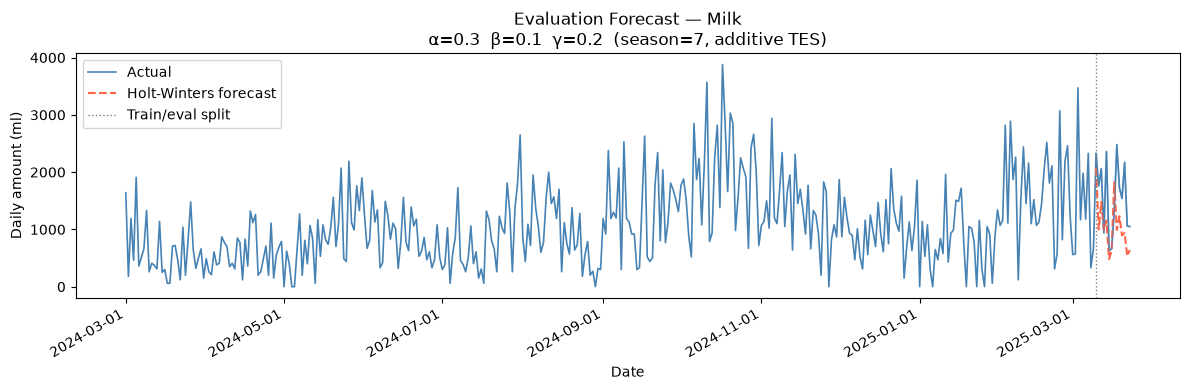

In [9]:
# ── Plot 1: Evaluation forecast (held-out period) ─────────────────────────────
hist = df[df['actual_amount'].notna()].copy()
eval_period = df[df['eval_forecast_amount'].notna()].copy()

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(hist['date'], hist['actual_amount'],
        color='steelblue', linewidth=1.2, label='Actual')
ax.plot(eval_period['date'], eval_period['eval_forecast_amount'],
        color='tomato', linewidth=1.5, linestyle='--', label='Holt-Winters forecast')
ax.plot(eval_period['date'], eval_period['actual_amount'],
        color='steelblue', linewidth=1.2, alpha=0.4)  # show actual for eval period too

if not eval_period.empty:
    ax.axvline(eval_period['date'].iloc[0], color='gray', linestyle=':', linewidth=1, label='Train/eval split')

ax.set_title(f'Evaluation Forecast — {INGREDIENT}\n'
             f'α={ALPHA}  β={BETA}  γ={GAMMA}  (season=7, additive TES)')
ax.set_xlabel('Date')
ax.set_ylabel(f'Daily amount ({unit})')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
fig.autofmt_xdate()
plt.tight_layout()

if SAVE_PLOTS:
    plt.savefig(OUT_EVAL, dpi=150)
    print(f'Saved: {OUT_EVAL}')
plt.show()

Saved: plot_future2.png


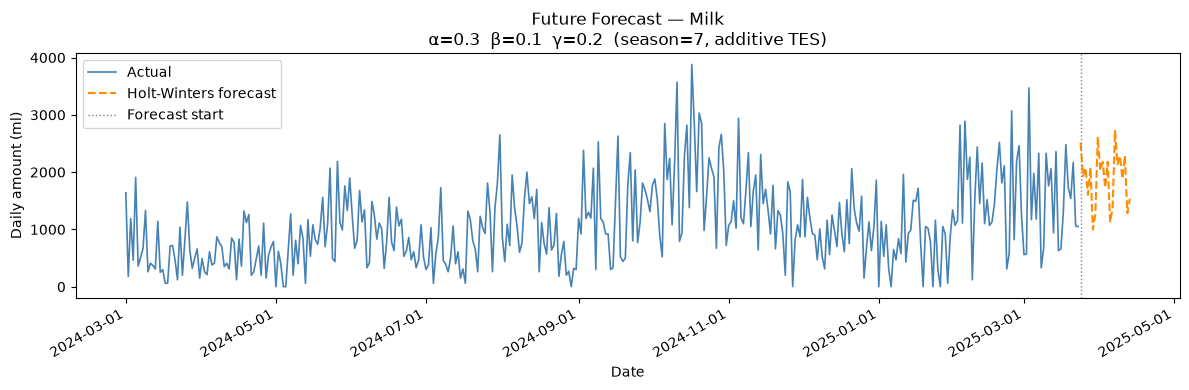

In [10]:
# ── Plot 2: Future forecast (beyond the dataset) ──────────────────────────────
future = df[df['future_forecast_amount'].notna()].copy()

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(hist['date'], hist['actual_amount'],
        color='steelblue', linewidth=1.2, label='Actual')
ax.plot(future['date'], future['future_forecast_amount'],
        color='darkorange', linewidth=1.5, linestyle='--', label='Holt-Winters forecast')

if not future.empty:
    ax.axvline(future['date'].iloc[0], color='gray', linestyle=':', linewidth=1, label='Forecast start')

ax.set_title(f'Future Forecast — {INGREDIENT}\n'
             f'α={ALPHA}  β={BETA}  γ={GAMMA}  (season=7, additive TES)')
ax.set_xlabel('Date')
ax.set_ylabel(f'Daily amount ({unit})')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
fig.autofmt_xdate()
plt.tight_layout()

if SAVE_PLOTS:
    plt.savefig(OUT_FUTURE, dpi=150)
    print(f'Saved: {OUT_FUTURE}')
plt.show()

In [ ]:
pg.close()